# Lab 2 - Análise Comparativa dos Modelos

Comparação de desempenho de todos os classificadores treinados nos notebooks 2A, 2B e 2C.
Métricas: Acurácia, **Balanced Accuracy**, Precision, Recall, F1-Score e Kappa.

> **Melhoria 3 (Pareto):** Balanced Accuracy substitui F1-Score como métrica de ranking.
> Com recall≈1 e precision≈0.5, o F1 fica inflado e não discrimina modelos bons de ruins.
> `Balanced Accuracy = (Recall_0 + Recall_1) / 2` não é inflada pelo colapso para uma classe.
> Dummies com Balanced Accuracy ≈ 0.5 confirmam quando um modelo não supera o acaso.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lab2_utils import (
    buscar_melhores_runs, carregar_dados,
    avaliar_modelo, logar_mlflow, iniciar_run,
)

X_train, y_train, X_test, y_test = carregar_dados()

Iniciando servidor MLflow em background...


Servidor MLflow pronto em http://127.0.0.1:5000
Dados carregados (gerados em 2026-06-25 21:29)
  X_train: (440832, 10)  |  X_test: (64374, 10)
  Features: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Subscription Type_Premium', 'Subscription Type_Standard']
  Churn rate treino: 0.567  |  teste: 0.474


## Baselines (DummyClassifier)

Antes de comparar os modelos entre si, precisamos saber se eles superam o **acaso**.

- `most_frequent`: prevê sempre a classe majoritária (churn=0 no teste) — baseline trivial
- `stratified`: prevê aleatoriamente respeitando a distribuição do treino

Um modelo real só é útil se sua **Balanced Accuracy > 0.5** (baseline dos Dummies).

In [2]:
from sklearn.dummy import DummyClassifier

dummies = [
    ('Dummy_MostFrequent', DummyClassifier(strategy='most_frequent', random_state=42)),
    ('Dummy_Stratified',   DummyClassifier(strategy='stratified',    random_state=42)),
]

for nome, dummy in dummies:
    params = {'modelo': nome, 'strategy': dummy.strategy}
    with iniciar_run(nome, notebook="3", params=params):
        dummy.fit(X_train, y_train)
        y_pred = dummy.predict(X_test)
        metricas = avaliar_modelo(nome, y_test, y_pred)
        logar_mlflow(metricas, params)


=== Dummy_MostFrequent ===
              precision    recall  f1-score   support

Não cancelou       0.00      0.00      0.00     33881
    Cancelou       0.47      1.00      0.64     30493

    accuracy                           0.47     64374
   macro avg       0.24      0.50      0.32     64374
weighted avg       0.22      0.47      0.30     64374

Balanced Accuracy: 0.5000  |  Kappa: 0.0000
🏃 View run Dummy_MostFrequent at: http://127.0.0.1:5000/#/experiments/1/runs/236baf3226954286bd5618a260839b1f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\saori\Desktop\ITA\PROF\PROF1.1\CMC-13\lab2\CMC13\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\saori\Desktop\ITA\PROF\PROF1.1\CMC-13\lab2\CMC13\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\saori\Desktop\ITA\PROF\PROF1.1\CMC-13\lab2\CMC13\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi


=== Dummy_Stratified ===
              precision    recall  f1-score   support

Não cancelou       0.52      0.43      0.47     33881
    Cancelou       0.47      0.57      0.51     30493

    accuracy                           0.49     64374
   macro avg       0.50      0.50      0.49     64374
weighted avg       0.50      0.49      0.49     64374

Balanced Accuracy: 0.4985  |  Kappa: -0.0030


🏃 View run Dummy_Stratified at: http://127.0.0.1:5000/#/experiments/1/runs/9c42ab681a504b25a4c37cdfa82dc46b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Carregamento das Métricas via MLflow

A função `buscar_melhores_runs()` do `lab2_utils.py` busca todos os runs finalizados
do experimento `Lab2-Churn` e deduplica automaticamente — mantém apenas o run mais
recente de cada modelo, ordenado por **Balanced Accuracy** (métrica principal a partir desta revisão).

In [3]:
df_metricas = buscar_melhores_runs()

print(f'Total de modelos registrados: {len(df_metricas)}')
df_metricas.sort_values('Balanced_Acc', ascending=False)

Total de modelos registrados: 9


,Acuracia,Balanced_Acc,Precision,Recall,F1-Score,Kappa
Modelo,,,,,,
SVM,0.584009,0.603988,0.533000,0.983603,0.691362,0.199542
AdaBoost,0.554230,0.576383,0.515222,0.997311,0.679439,0.145939
DecisionTree,0.554012,0.576113,0.515120,0.996032,0.679053,0.145437
KNN,0.545205,0.567524,0.510260,0.991605,0.673798,0.128965
RandomForest,0.519138,0.543089,0.496234,0.998164,0.662906,0.082029
XGBoost,0.518626,0.542597,0.495967,0.998065,0.662646,0.081089
MLP,0.518113,0.542139,0.495703,0.998655,0.662540,0.080210
Dummy_MostFrequent,0.473685,0.500000,0.473685,1.000000,0.642858,0.000000
Dummy_Stratified,0.494936,0.498486,0.472355,0.565933,0.514927,-0.002999


## Comparação de Métricas

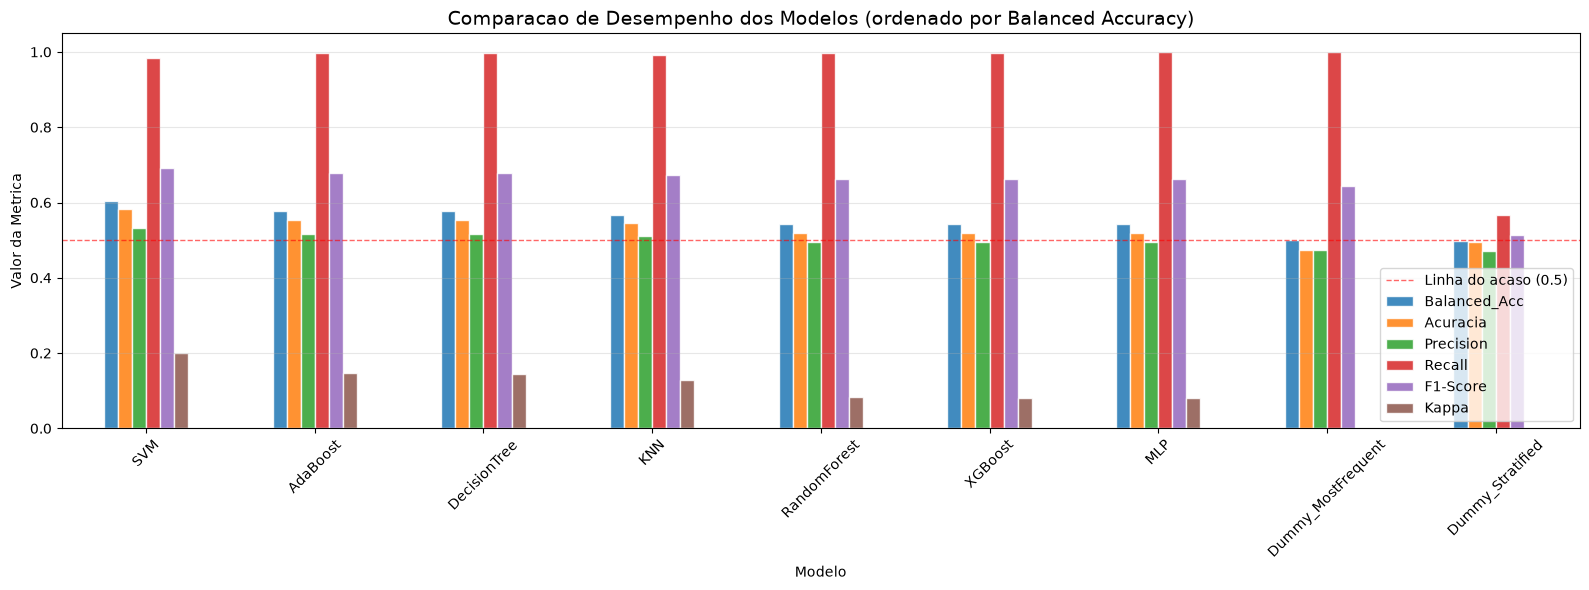

In [4]:
metricas_cols = ['Balanced_Acc', 'Acuracia', 'Precision', 'Recall', 'F1-Score', 'Kappa']

df_plot = df_metricas[metricas_cols].sort_values('Balanced_Acc', ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
df_plot.plot.bar(ax=ax, edgecolor='white', alpha=0.85)
ax.set_title('Comparacao de Desempenho dos Modelos (ordenado por Balanced Accuracy)', fontsize=14)
ax.set_ylabel('Valor da Metrica')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Linha do acaso (0.5)')
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../relatorio/imagens/3_comp_barplot_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## Ranking dos Modelos

In [5]:
print('=== Ranking por Balanced Accuracy (metrica principal) ===')
print(df_metricas.sort_values('Balanced_Acc', ascending=False)[metricas_cols].to_string())

print('\n=== Ranking por Kappa ===')
print(df_metricas.sort_values('Kappa', ascending=False)[metricas_cols].to_string())

print('\n=== Dummies (linha do acaso) ===')
dummies_idx = [m for m in df_metricas.index if 'Dummy' in str(m)]
if dummies_idx:
    print(df_metricas.loc[dummies_idx, metricas_cols].to_string())

=== Ranking por Balanced Accuracy (metrica principal) ===
                    Balanced_Acc  Acuracia  Precision    Recall  F1-Score     Kappa
Modelo                                                                             
SVM                     0.603988  0.584009   0.533000  0.983603  0.691362  0.199542
AdaBoost                0.576383  0.554230   0.515222  0.997311  0.679439  0.145939
DecisionTree            0.576113  0.554012   0.515120  0.996032  0.679053  0.145437
KNN                     0.567524  0.545205   0.510260  0.991605  0.673798  0.128965
RandomForest            0.543089  0.519138   0.496234  0.998164  0.662906  0.082029
XGBoost                 0.542597  0.518626   0.495967  0.998065  0.662646  0.081089
MLP                     0.542139  0.518113   0.495703  0.998655  0.662540  0.080210
Dummy_MostFrequent      0.500000  0.473685   0.473685  1.000000  0.642858  0.000000
Dummy_Stratified        0.498486  0.494936   0.472355  0.565933  0.514927 -0.002999

=== Ranking por K